In [2]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt
from call_back import myCallback

In [3]:
dataset = tf.keras.datasets.mnist

In [4]:
(X_train,y_train),(X_test,y_test) = dataset.load_data()

In [5]:
# normalizing the datasets
X_train, X_test = X_train/255, X_test/255

In [6]:
index = 49

In [7]:
print(f"training_Label:   {y_train[index]}\n\n\n")
print("training_data::",(X_train[index]))

training_Label:   3



training_data:: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.   

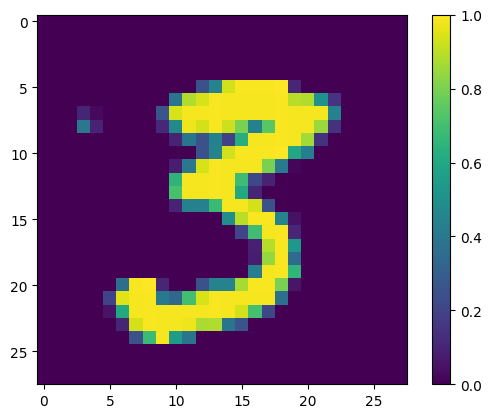

In [8]:
plt.imshow(X_train[index])
plt.colorbar()
plt.show()

In [9]:
model = tf.keras.Sequential(
    [
        # upgrade according to week 3 requirement 
        # modification starts
        tf.keras.Input(shape=(28,28,1)),

        
        tf.keras.layers.Conv2D(32,(3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        # modification stops
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation=tf.nn.relu),
        # tf.keras.layers.Dense(256, activation=tf.nn.relu),
        tf.keras.layers.Dense(10, activation=tf.nn.softmax)
    ]
)

In [10]:
# model compilation 

model.compile(
    optimizer="adam",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    # loss='sparse_categorical_crossentropy',
    metrics=["accuracy"])

In [11]:
model.fit(X_train, y_train, epochs=10, callbacks=[myCallback()])

Epoch 1/10


c:\Users\dipak\.conda\envs\env2\Lib\site-packages\keras\src\backend\tensorflow\nn.py:635: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 41ms/step - accuracy: 0.9277 - loss: 0.2429
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 40ms/step - accuracy: 0.9882 - loss: 0.0385
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - accuracy: 0.9933 - loss: 0.0204
Epoch 4/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9961 - loss: 0.0127Reached 99.5% accuracy so cancelling training!
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 42ms/step - accuracy: 0.9961 - loss: 0.0127


In [13]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9755 - loss: 0.0916


[0.06925550848245621, 0.9805999994277954]